## Apply PyOD ECOD to IDC plate, train logistic regression model and run bootstrap evaluation

In [1]:
import random
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from cytodataframe import CytoDataFrame
from joblib import dump, load, parallel_backend
from pycytominer import annotate, feature_select, normalize
from pyod.models.ecod import ECOD
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder

sys.path.append("../figure_3")
import matplotlib.pyplot as plt
from figure3_utils import downsample_data, get_X_y_data
from PyComplexHeatmap import (
    ClusterMapPlotter,
    HeatmapAnnotation,
    anno_simple,
)

## Step 1: Load in converted profiles from IDC plate

In [2]:
# Set model directory path
model_dir = Path("./models")
model_dir.mkdir(exist_ok=True)

In [3]:
# Load dataframe
idc_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/converted_profiles/localhost231120090001_converted.parquet"
    )
)

print(idc_df.shape)
idc_df.head()

(20856, 2016)


,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Image_Metadata_Plate,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,...,Nuclei_Texture_Variance_Hoechst_3_02_256,Nuclei_Texture_Variance_Hoechst_3_03_256,Nuclei_Texture_Variance_Mitochondria_3_00_256,Nuclei_Texture_Variance_Mitochondria_3_01_256,Nuclei_Texture_Variance_Mitochondria_3_02_256,Nuclei_Texture_Variance_Mitochondria_3_03_256,Nuclei_Texture_Variance_PM_3_00_256,Nuclei_Texture_Variance_PM_3_01_256,Nuclei_Texture_Variance_PM_3_02_256,Nuclei_Texture_Variance_PM_3_03_256
0,787.816143,113.743274,832.342493,109.226914,18,1,localhost231120090001,f00,B02,1,...,8.660138,8.737496,2.402478,2.424327,2.378789,2.426765,6.195450,6.115798,5.953039,5.982729
1,612.015315,258.122523,583.551435,220.881555,18,1,localhost231120090001,f00,B02,2,...,2.916384,2.935153,0.749391,0.760774,0.757014,0.778893,6.014494,5.914774,7.516835,6.266337
2,54.977129,271.567823,69.468928,289.697152,18,1,localhost231120090001,f00,B02,3,...,4.680699,4.630538,0.415534,0.413480,0.408241,0.410364,62.191540,63.640391,61.296605,63.573675
3,199.395062,268.792593,193.914743,269.641581,18,1,localhost231120090001,f00,B02,4,...,2.682473,2.711816,0.417965,0.413393,0.391549,0.385171,1.871388,1.714265,1.808903,1.785609
4,531.072041,276.144082,524.886555,279.036043,18,1,localhost231120090001,f00,B02,5,...,2.151674,2.123986,0.270058,0.275807,0.268517,0.268072,0.775387,0.777194,0.763620,0.735567


## Step 2: Perform ECOD on the converted profiles to flag and drop outlier cells

In [4]:
# Identify columns to drop (metadata only)
drop_cols = idc_df.columns[
    idc_df.columns.str.startswith("Image_Metadata")
    | idc_df.columns.str.startswith("Metadata_")
    | idc_df.columns.str.startswith("Image_FileName")
]

# Feature matrix
X = idc_df.drop(columns=drop_cols)

# Drop columns with ANY NaNs in features (required for ECOD to work)
X_clean = X.loc[:, ~X.isna().any()]

# Fit ECOD
ecod = ECOD(contamination=0.192, n_jobs=-1)
ecod.fit(X_clean)

# Predict labels
ecod_labels = ecod.labels_

# Store results back ONLY for valid rows
idc_df["ECOD_flag"] = np.nan
idc_df.loc[X_clean.index, "ECOD_flag"] = ecod_labels

# Print number of outliers detected
print(f"Number of outliers detected by ECOD: {np.sum(ecod_labels)}")

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    4.0s remaining:   28.0s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    5.4s finished
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/pyod/models/ecod.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return np.nan_to_num(skew_sp(X, axis=axis))


Number of outliers detected by ECOD: 4005


## Step 3: Perform pycytominer preprocessing steps (same as original)

In [5]:
# Set platemap path
platemap_path = Path(
    "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/metadata/localhost231120090001_platemap.csv"
)
# Load platemap
platemap_df = pd.read_csv(platemap_path)

# Step 1: Annotation
print("Running annotation...")
idc_annotated_df = annotate(
    profiles=idc_df,
    platemap=platemap_df,
    join_on=["Metadata_well_position", "Image_Metadata_Well"],
)

# Rename columns using the rename() function
column_name_mapping = {
    "Image_Metadata_Site": "Metadata_Site",
}

idc_annotated_df.rename(columns=column_name_mapping, inplace=True)

# Drop any row that is flagged by ECOD as an outlier
idc_annotated_df_filtered = idc_annotated_df[idc_annotated_df["ECOD_flag"] == 0]

# Step 2: Normalization
print("Running normalization...")
idc_normalized_df = normalize(
    profiles=idc_annotated_df_filtered,
    method="standardize",
    samples="Metadata_heart_number == 7 and Metadata_treatment == 'DMSO'",
)

# Step 3: Feature selection
print("Running feature selection...")
idc_norm_fs_df = feature_select(
    idc_normalized_df,
    operation=[
        "variance_threshold",
        "correlation_threshold",
        "blocklist",
        "drop_na_columns",
    ],
    na_cutoff=0,
)

print(idc_norm_fs_df.shape)
idc_norm_fs_df.head()

Running annotation...
Running normalization...
Running feature selection...
(16851, 720)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_00_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumEntropy_ER_3_01_256,Nuclei_Texture_SumVariance_ER_3_03_256,Nuclei_Texture_SumVariance_Hoechst_3_03_256,Nuclei_Texture_SumVariance_Mitochondria_3_03_256,Nuclei_Texture_SumVariance_PM_3_03_256
0,B,2,2,Healthy,NaN,NaN,787.816143,113.743274,832.342493,109.226914,...,-0.643349,-1.254812,-1.159315,-0.833481,-0.295979,0.658109,-0.200459,0.267328,0.071874,0.063624
1,B,2,2,Healthy,NaN,NaN,612.015315,258.122523,583.551435,220.881555,...,0.333148,0.070514,0.443029,-0.249172,-0.408999,-0.718298,-0.351528,-0.369120,-0.262574,-0.042912
2,B,2,2,Healthy,NaN,NaN,54.977129,271.567823,69.468928,289.697152,...,0.385370,0.666527,-1.298878,-0.891214,-0.908844,-0.524585,-0.384837,-0.209967,-0.322095,7.282225
3,B,2,2,Healthy,NaN,NaN,199.395062,268.792593,193.914743,269.641581,...,0.509150,0.943828,0.644503,0.806925,0.972189,-0.690465,-0.433523,-0.391487,-0.315930,-0.429487
4,B,2,2,Healthy,NaN,NaN,531.072041,276.144082,524.886555,279.036043,...,0.561544,0.493431,1.699425,1.408957,1.464555,-0.640198,-0.408787,-0.467798,-0.344137,-0.553585


In [6]:
# Save the feature selected profile after dropping ECOD cells
idc_norm_fs_df.to_parquet(
    model_dir / "idc_normalized_feature_selected.parquet", index=False
)

In [7]:
# Summary of ECOD failures by heart number and treatment
ecod_failed = idc_annotated_df["ECOD_flag"] == 1

summary = (
    idc_annotated_df.groupby(["Metadata_heart_number"])
    .agg(total_cells=("ECOD_flag", "size"),
         ecod_failed_count=("ECOD_flag", lambda s: (s == 1).sum()))
    .reset_index()
)

summary["ecod_failed_pct"] = summary["ecod_failed_count"] / summary["total_cells"] * 100

summary.head()

,Metadata_heart_number,total_cells,ecod_failed_count,ecod_failed_pct
0,2,2865,494,17.242583
1,4,4025,662,16.447205
2,7,4820,1061,22.012448
3,19,3532,501,14.184598
4,23,2918,444,15.215901


## Step 4: Perform data splits for holdout, training, and testing

### Holdout heart #7 DMSO and heart #29 (the same as the other two original models)

In [8]:
# Copy all DMSO heart #7 rows into the holdout_df
holdout_df = idc_norm_fs_df[
    (idc_norm_fs_df["Metadata_heart_number"] == 7)
    & (idc_norm_fs_df["Metadata_treatment"] == "DMSO")
    | (idc_norm_fs_df["Metadata_heart_number"] == 29)
]

# Check shape and output
print(
    "The shape of the holdout data frame after removing DMSO heart 7 and heart 29 is",
    holdout_df.shape,
)
holdout_df.head()

The shape of the holdout data frame after removing DMSO heart 7 and heart 29 is (2807, 720)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_00_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumEntropy_ER_3_01_256,Nuclei_Texture_SumVariance_ER_3_03_256,Nuclei_Texture_SumVariance_Hoechst_3_03_256,Nuclei_Texture_SumVariance_Mitochondria_3_03_256,Nuclei_Texture_SumVariance_PM_3_03_256
3161,B,10,7,Healthy,NaN,DMSO,469.048643,155.781674,440.719879,177.033188,...,-0.145770,-0.415182,0.535323,-0.109753,0.110647,0.346538,-0.203452,0.143057,-0.193550,-0.157573
3162,B,10,7,Healthy,NaN,DMSO,836.303219,234.888889,847.646056,205.670039,...,-0.107503,0.296236,0.863168,0.740246,0.007830,0.260907,-0.067817,-0.084109,-0.086349,-0.306794
3163,B,10,7,Healthy,NaN,DMSO,203.850902,252.441595,235.742035,269.541554,...,1.198371,0.620342,0.720329,0.217162,0.476432,-0.322098,-0.359101,-0.299073,-0.316963,-0.282006
3166,B,10,7,Healthy,NaN,DMSO,590.450266,355.174956,599.530776,336.153480,...,0.093376,0.801227,0.836261,0.994806,1.232314,-1.243875,-0.456327,-0.468485,-0.215527,-0.404818
3167,B,10,7,Healthy,NaN,DMSO,246.878657,369.340195,258.638058,366.616757,...,0.094715,0.095108,-0.386390,-0.288078,0.047705,-1.358877,-0.447159,0.006009,-0.285095,0.003576


### Drop random wells

In [9]:
# Add random seed to this code cell as well to avoid change the random well if this code cell if rerun
random.seed(0)

# Create new df which removes the holdout data from the idc_norm_fs_df which will be used to find random wells from rest of the data
# Define constants for heart numbers and treatment
HEART_NUMBER_HOLDOUT = 29
HEART_NUMBER_DMSO = 7
TREATMENT_DMSO = "DMSO"
CELL_TYPE_FAILING = "Failing"

mask = (
    (idc_norm_fs_df["Metadata_heart_number"] == HEART_NUMBER_HOLDOUT)
    & (idc_norm_fs_df["Metadata_cell_type"] == CELL_TYPE_FAILING)
) | (
    (idc_norm_fs_df["Metadata_heart_number"] == HEART_NUMBER_DMSO)
    & (idc_norm_fs_df["Metadata_treatment"] == TREATMENT_DMSO)
)

idc_norm_fs_df_filtered = idc_norm_fs_df.loc[~mask]

# Generate random well per heart number to add to holdout_df
random_wells = (
    idc_norm_fs_df_filtered.groupby("Metadata_heart_number")["Metadata_Well"]
    .apply(
        lambda x: random.choice(sorted(x.unique()))
    )  # Selecting a random well from sorted unique values
    .reset_index(name="Random_Metadata_Well")
)

# Filter plate_4_df_filtered based on Metadata_heart_number and Metadata_Well in random_wells
matched_rows = idc_norm_fs_df_filtered[
    (
        idc_norm_fs_df_filtered["Metadata_heart_number"].isin(
            random_wells["Metadata_heart_number"]
        )
    )
    & (
        idc_norm_fs_df_filtered["Metadata_Well"].isin(
            random_wells["Random_Metadata_Well"]
        )
    )
]

# Add matching rows to the holdout data frame
holdout_df_wells = pd.concat([holdout_df, matched_rows], ignore_index=True)

# Check shape and output
print("There were", matched_rows.shape[0], "rows matching the random wells per heart")
print(
    "The shape of the holdout data frame after removing a random well per heart is",
    holdout_df_wells.shape,
)
holdout_df_wells.head()

There were 1477 rows matching the random wells per heart
The shape of the holdout data frame after removing a random well per heart is (4284, 720)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_00_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumEntropy_ER_3_01_256,Nuclei_Texture_SumVariance_ER_3_03_256,Nuclei_Texture_SumVariance_Hoechst_3_03_256,Nuclei_Texture_SumVariance_Mitochondria_3_03_256,Nuclei_Texture_SumVariance_PM_3_03_256
0,B,10,7,Healthy,NaN,DMSO,469.048643,155.781674,440.719879,177.033188,...,-0.145770,-0.415182,0.535323,-0.109753,0.110647,0.346538,-0.203452,0.143057,-0.193550,-0.157573
1,B,10,7,Healthy,NaN,DMSO,836.303219,234.888889,847.646056,205.670039,...,-0.107503,0.296236,0.863168,0.740246,0.007830,0.260907,-0.067817,-0.084109,-0.086349,-0.306794
2,B,10,7,Healthy,NaN,DMSO,203.850902,252.441595,235.742035,269.541554,...,1.198371,0.620342,0.720329,0.217162,0.476432,-0.322098,-0.359101,-0.299073,-0.316963,-0.282006
3,B,10,7,Healthy,NaN,DMSO,590.450266,355.174956,599.530776,336.153480,...,0.093376,0.801227,0.836261,0.994806,1.232314,-1.243875,-0.456327,-0.468485,-0.215527,-0.404818
4,B,10,7,Healthy,NaN,DMSO,246.878657,369.340195,258.638058,366.616757,...,0.094715,0.095108,-0.386390,-0.288078,0.047705,-1.358877,-0.447159,0.006009,-0.285095,0.003576


### Drop holdout data and then split into train and testing data

In [10]:
# Build the holdout mask (same conditions as above)
holdout_mask = (
    (
        (idc_norm_fs_df["Metadata_heart_number"] == 29)
        & (idc_norm_fs_df["Metadata_cell_type"] == "Failing")
    )
    | (
        (idc_norm_fs_df["Metadata_heart_number"] == 7)
        & (idc_norm_fs_df["Metadata_treatment"] == "DMSO")
    )
    | (
        (idc_norm_fs_df["Metadata_heart_number"].isin(random_wells["Metadata_heart_number"]))
        & (idc_norm_fs_df["Metadata_Well"].isin(random_wells["Random_Metadata_Well"]))
    )
)

# Rows NOT matching the mask = data used for training
idc_norm_fs_df_dropped_holdout = idc_norm_fs_df[~holdout_mask]

# Rows matching the mask = the held-out cells only
idc_holdout_df = idc_norm_fs_df[holdout_mask]

# Save the held-out data as its own dataframe for later use
idc_holdout_df.to_parquet(
    model_dir / "idc_holdout_data.parquet", index=False
)

print(idc_norm_fs_df_dropped_holdout.shape)
print(idc_holdout_df.shape)
idc_norm_fs_df_dropped_holdout.head()

(12567, 720)
(4284, 720)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_00_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumEntropy_ER_3_01_256,Nuclei_Texture_SumVariance_ER_3_03_256,Nuclei_Texture_SumVariance_Hoechst_3_03_256,Nuclei_Texture_SumVariance_Mitochondria_3_03_256,Nuclei_Texture_SumVariance_PM_3_03_256
0,B,2,2,Healthy,NaN,NaN,787.816143,113.743274,832.342493,109.226914,...,-0.643349,-1.254812,-1.159315,-0.833481,-0.295979,0.658109,-0.200459,0.267328,0.071874,0.063624
1,B,2,2,Healthy,NaN,NaN,612.015315,258.122523,583.551435,220.881555,...,0.333148,0.070514,0.443029,-0.249172,-0.408999,-0.718298,-0.351528,-0.369120,-0.262574,-0.042912
2,B,2,2,Healthy,NaN,NaN,54.977129,271.567823,69.468928,289.697152,...,0.385370,0.666527,-1.298878,-0.891214,-0.908844,-0.524585,-0.384837,-0.209967,-0.322095,7.282225
3,B,2,2,Healthy,NaN,NaN,199.395062,268.792593,193.914743,269.641581,...,0.509150,0.943828,0.644503,0.806925,0.972189,-0.690465,-0.433523,-0.391487,-0.315930,-0.429487
4,B,2,2,Healthy,NaN,NaN,531.072041,276.144082,524.886555,279.036043,...,0.561544,0.493431,1.699425,1.408957,1.464555,-0.640198,-0.408787,-0.467798,-0.344137,-0.553585


In [11]:
# Set random state as 0 (same as the rest of the notebook)
random_state = 0

# Set the ratio of the test data to 30% (training data will be 70%)
test_ratio = 0.30

# Split the plate 4 data into training and test
training_data, testing_data = train_test_split(
    idc_norm_fs_df_dropped_holdout,
    test_size=test_ratio,
    stratify=idc_norm_fs_df_dropped_holdout[["Metadata_cell_type"]],
    random_state=random_state,
)

# Save the training and testing data as separate parquet files for later use
training_data.to_parquet(
    model_dir / "idc_training_data.parquet", index=False
)
testing_data.to_parquet(
    model_dir / "idc_testing_data.parquet", index=False
)

# View shapes and example output
print("The testing data contains", testing_data.shape[0], "single-cells.")
print("The training data contains", training_data.shape[0], "single-cells.")
testing_data.head()

The testing data contains 3771 single-cells.
The training data contains 8796 single-cells.


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_00_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumEntropy_ER_3_01_256,Nuclei_Texture_SumVariance_ER_3_03_256,Nuclei_Texture_SumVariance_Hoechst_3_03_256,Nuclei_Texture_SumVariance_Mitochondria_3_03_256,Nuclei_Texture_SumVariance_PM_3_03_256
19211,G,6,4,Failing,Dilated_Cardiomyopathy,NaN,878.461355,330.407968,865.777345,369.759069,...,1.772847,1.584964,1.632345,1.469760,1.342756,-1.860862,-0.490307,-0.535374,-0.364962,-0.531115
10866,D,11,4,Failing,Dilated_Cardiomyopathy,NaN,662.545652,870.120652,656.810633,817.523406,...,-2.408152,-1.787730,-0.456134,-2.495172,-3.502098,1.551648,0.448439,0.168189,0.476291,2.727412
2828,B,9,19,Failing,Dilated_Cardiomyopathy,NaN,221.733491,225.991981,221.733491,225.991981,...,0.377755,-0.613836,-0.343819,-0.868773,-0.436992,0.994939,0.103455,0.100579,-0.001516,0.557231
839,B,4,2,Healthy,NaN,NaN,824.094395,511.983284,812.609376,483.848199,...,0.331690,1.094778,0.070248,0.314814,-0.171107,-0.249508,-0.387323,-0.286464,-0.296044,-0.216831
5471,C,7,23,Failing,Dilated_Cardiomyopathy,NaN,851.492117,225.203829,824.101942,210.700550,...,-0.866996,-1.647814,-0.110991,-0.408270,-0.260422,1.649824,0.892922,1.012835,0.578770,1.120588


## Step 5: Train logreg model using ECOD-filtered data

In [12]:
# load in training plate 4 data as downsampled to lowest class
label = "Metadata_cell_type"
downsample_df = downsample_data(df=training_data, label=label)

# Export sample indices used in training the model to a new one-column CSV file
output_file = "training_data_indices.csv"
pd.DataFrame(downsample_df.index, columns=["Index"]).to_csv(output_file, index=False)

print(f"CSV file created at {output_file} with {len(downsample_df.index)} entries.")

print(downsample_df.shape)
print(downsample_df["Metadata_cell_type"].value_counts())
downsample_df.head()

CSV file created at training_data_indices.csv with 6470 entries.
(6470, 720)
Metadata_cell_type
Failing    3235
Healthy    3235
Name: count, dtype: int64


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_00_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_02_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumEntropy_ER_3_01_256,Nuclei_Texture_SumVariance_ER_3_03_256,Nuclei_Texture_SumVariance_Hoechst_3_03_256,Nuclei_Texture_SumVariance_Mitochondria_3_03_256,Nuclei_Texture_SumVariance_PM_3_03_256
0,G,8,4,Failing,Dilated_Cardiomyopathy,NaN,414.555178,107.373514,413.918740,143.819630,...,1.095785,1.372494,0.896171,1.003468,0.771976,-0.564975,-0.421875,-0.190353,-0.358302,-0.417963
1,D,8,4,Failing,Dilated_Cardiomyopathy,NaN,953.915327,424.919614,956.053124,424.090564,...,-0.085574,0.314086,-0.393104,-0.357656,-1.133656,0.601977,0.015543,-0.248519,-0.132920,-0.047475
2,G,2,4,Failing,Dilated_Cardiomyopathy,NaN,643.074434,177.431499,619.007562,177.817393,...,0.443441,0.359550,0.731766,0.540407,0.664696,0.168234,-0.196037,0.325443,-0.269882,-0.410353
3,E,5,19,Failing,Dilated_Cardiomyopathy,NaN,1010.191150,494.702655,1008.054468,492.339523,...,-0.422699,-0.455814,0.992154,1.218505,1.498272,0.158079,-0.339866,-0.452963,0.235191,-0.451708
4,E,11,19,Failing,Dilated_Cardiomyopathy,NaN,867.949195,262.821561,870.781042,269.188043,...,-3.254482,-1.501445,-2.354343,-2.706970,-3.572995,1.362431,0.257909,2.369658,-0.085682,3.614758


In [13]:
# Get not shuffled training data from downsampled df (e.g., "final")
X_train, y_train = get_X_y_data(df=downsample_df, label=label, shuffle=False)

# Get shuffled training data from downsampled df(e.g., "shuffled_baseline")
X_shuffled_train, y_shuffled_train = get_X_y_data(
    df=downsample_df, label=label, shuffle=True
)

In [14]:
# Encode classes
le = LabelEncoder()
le.fit(y_train)
# Fit the labels onto the shuffled and non-shuffled data
y_train = le.transform(y_train)
y_shuffled_train = le.transform(y_shuffled_train)

# Print the original classes and their corresponding encoded values
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class Mapping:")
print(class_mapping)

Class Mapping:
{'Failing': np.int64(0), 'Healthy': np.int64(1)}


In [15]:
# Set folds for k-fold cross validation (default is 5)
straified_k_folds = StratifiedKFold(n_splits=10, shuffle=False)

# Set Logistic Regression model parameters (use default for max_iter)
logreg_params = {
    "penalty": "elasticnet",
    "solver": "saga",
    "max_iter": 1000,
    "n_jobs": -1,
    "random_state": 0,
    "class_weight": "balanced",
}

# Define the hyperparameter search space for RandomizedSearchCV
param_dist = {
    "C": np.logspace(-3, 3, 7),
    "l1_ratio": np.linspace(0, 1, 11),
}

# Set the random search hyperparameterization method parameters (used default for "cv" and "n_iter" parameter)
random_search_params = {
    "param_distributions": param_dist,
    "scoring": "f1_weighted",
    "random_state": 0,
    "n_jobs": -1,
    "cv": straified_k_folds,
}

In [16]:
# Check if the "models" folder contains a file with "final" in its name
if any(model_dir.glob("*final*")):
    print("Model training skipped as a 'final' model already exists.")
    pass
else:
    # Generate logistic regression model for non-shuffled training data
    final_logreg = LogisticRegression(**logreg_params)

    # Initialize the RandomizedSearchCV
    final_random_search = RandomizedSearchCV(final_logreg, **random_search_params)

    # Prevent the convergence warning in sklearn, it does not impact the result
    with parallel_backend("multiprocessing"), warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
        # Perform the random hyperparameter search
        final_random_search.fit(X_train, y_train)

        # Print the best parameters
        print("Optimal parameters:", final_random_search.best_params_)

Model training skipped as a 'final' model already exists.


In [17]:
# Check if the "models" folder contains a file with "final" in its name
if any(model_dir.glob("*shuffled*")):
    print("Model training skipped as a 'shuffled' model already exists.")
    pass
else:
    # Generate logistic regression model for shuffled training data
    shuffled_logreg = LogisticRegression(**logreg_params)

    # Initialize the RandomizedSearchCV
    shuffled_random_search = RandomizedSearchCV(shuffled_logreg, **random_search_params)

    # Prevent the convergence warning in sklearn, it does not impact the result
    with parallel_backend("multiprocessing"), warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
        # Perform the random hyperparameter search
        shuffled_random_search.fit(X_shuffled_train, y_shuffled_train)

Model training skipped as a 'shuffled' model already exists.


In [18]:
data_prefix = "log_reg_fs_ecod"

# Check if there are models with "final" or "shuffled" in its name that exists in the models folder
if any(model_dir.glob("*final*")) or any(model_dir.glob("*shuffled*")):
    print(
        "No models were generated or saved because 'final' and/or 'shuffled' files already exist. Loading in existing models..."
    )
    # Load in the existing models
    final_random_search = load(model_dir / f"{data_prefix}_final_downsample.joblib")
    shuffled_random_search = load(model_dir / f"{data_prefix}_shuffled_downsample.joblib")
else:
    # Save the models
    dump(
        final_random_search.best_estimator_,
        f"{model_dir}/{data_prefix}_final_downsample.joblib",
    )
    dump(
        shuffled_random_search.best_estimator_,
        f"{model_dir}/{data_prefix}_shuffled_downsample.joblib",
    )

    print("Models and label encoder have been saved!")

No models were generated or saved because 'final' and/or 'shuffled' files already exist. Loading in existing models...


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Step 6: Load in coSMicQC passing cells to label IDC plate with coSMicQC flags

In [19]:
# Load cosmicqc data
cosmicQC_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost231120090001_sc_annotated.parquet"
    )
)

# Columns that uniquely identify a cell
cell_id_cols = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Number_Object_Number",
]

# Update idc_df to have the same cell identifier columns as cosmicQC_df (if needed)
idc_df = idc_df.rename(
    columns={
        "Image_Metadata_Plate": "Metadata_Plate",
        "Image_Metadata_Well": "Metadata_Well",
        "Image_Metadata_Site": "Metadata_Site",
        "Image_Metadata_Nuclei_Number_Object_Number": "Metadata_Nuclei_Number_Object_Number",
    }
)

# Default all cells to failed QC
idc_df["cosmicqc_label"] = "failed_qc"

# Label cells that are present in the QC dataframe as passed QC
idc_df.loc[
    idc_df.set_index(cell_id_cols).index.isin(
        cosmicQC_df.set_index(cell_id_cols).index
    ),
    "cosmicqc_label",
] = "passed_qc"

# Check counts
print(idc_df["cosmicqc_label"].value_counts())

# Compare CosmicQC labels with ECOD outlier labels
comparison_df = pd.crosstab(
    idc_df["cosmicqc_label"],
    idc_df["ECOD_flag"],
    margins=True,
)

print(comparison_df)

cosmicqc_label
passed_qc    16860
failed_qc     3996
Name: count, dtype: int64
ECOD_flag         0.0   1.0    All
cosmicqc_label                    
failed_qc        1805  2191   3996
passed_qc       15046  1814  16860
All             16851  4005  20856


## Step 7: Evaluate agreement between ECOD and coSMicQC on IDC plate

In [20]:
# Agreement between ECOD and coSMicQC
cosmicqc_failed = idc_df["cosmicqc_label"] == "failed_qc"
ecod_failed = idc_df["ECOD_flag"] == 1

agreement = (cosmicqc_failed == ecod_failed).sum()
agreement_pct = agreement / len(idc_df) * 100

print(f"\nOverall agreement: {agreement_pct:.2f}%")
print(f"Matching labels: {agreement:,} / {len(idc_df):,}")

# Confusion matrix
comparison_df = pd.crosstab(
    idc_df["cosmicqc_label"],
    idc_df["ECOD_flag"],
    margins=True,
)

print("\ncoSMicQC vs ECOD")
print(comparison_df)

# How many coSMicQC failures were also ECOD outliers?
failed_qc_df = idc_df[idc_df["cosmicqc_label"] == "failed_qc"]

ecod_overlap_pct = failed_qc_df["ECOD_flag"].eq(1).mean() * 100

print(
    f"\ncoSMicQC failed cells also flagged by ECOD: "
    f"{ecod_overlap_pct:.2f}% "
    f"({failed_qc_df['ECOD_flag'].eq(1).sum():,} / {len(failed_qc_df):,})"
)

# How many ECOD outliers were also coSMicQC failures?
ecod_df = idc_df[idc_df["ECOD_flag"] == 1]

cosmic_overlap_pct = (
    ecod_df["cosmicqc_label"].eq("failed_qc").mean() * 100
)

print(
    f"ECOD outliers also flagged by coSMicQC: "
    f"{cosmic_overlap_pct:.2f}% "
    f"({ecod_df['cosmicqc_label'].eq('failed_qc').sum():,} / {len(ecod_df):,})"
)


Overall agreement: 82.65%
Matching labels: 17,237 / 20,856

coSMicQC vs ECOD
ECOD_flag         0.0   1.0    All
cosmicqc_label                    
failed_qc        1805  2191   3996
passed_qc       15046  1814  16860
All             16851  4005  20856

coSMicQC failed cells also flagged by ECOD: 54.83% (2,191 / 3,996)
ECOD outliers also flagged by coSMicQC: 54.71% (2,191 / 4,005)


## Step 8: Create Venn Diagram of cells that failed either or both QC methods

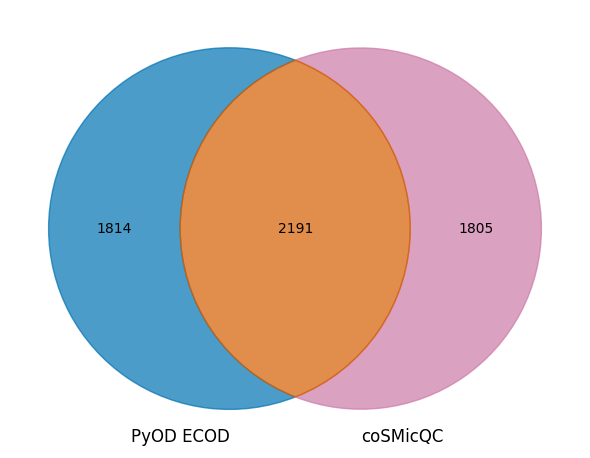

In [21]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# -----------------------------
# DEFINE MASKS
# -----------------------------
cosmic_fail = idc_df["cosmicqc_label"] == "failed_qc"
ecod_fail = idc_df["ECOD_flag"] == 1

cosmic_only = cosmic_fail & ~ecod_fail
ecod_only = ecod_fail & ~cosmic_fail
both = cosmic_fail & ecod_fail

# -----------------------------
# COUNTS
# -----------------------------
ecod_only_count = ecod_only.sum()
cosmic_only_count = cosmic_only.sum()
both_count = both.sum()

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(6, 6))

venn = venn2(
    subsets=(ecod_only_count, cosmic_only_count, both_count),
    set_labels=("PyOD ECOD", "coSMicQC"),
    alpha=0.7
)

# -----------------------------
# MANUALLY SET REGION COLORS
# -----------------------------
# ECOD only
if venn.get_patch_by_id("10"):
    venn.get_patch_by_id("10").set_color("#0072B2")  # blue

# coSMicQC only
if venn.get_patch_by_id("01"):
    venn.get_patch_by_id("01").set_color("#CC79A7")  # green

# overlap (both methods)
if venn.get_patch_by_id("11"):
    venn.get_patch_by_id("11").set_color("#D55E00")  # orange

# -----------------------------
# ADD COUNTS (override labels cleanly)
# -----------------------------
if venn.get_label_by_id("10"):
    venn.get_label_by_id("10").set_text(ecod_only_count)

if venn.get_label_by_id("01"):
    venn.get_label_by_id("01").set_text(cosmic_only_count)

if venn.get_label_by_id("11"):
    venn.get_label_by_id("11").set_text(both_count)

# -----------------------------
# TITLE + STYLE
# -----------------------------
plt.tight_layout()
plt.savefig("./figures/cosmicqc_ecod_venn_diagram.png", dpi=600)
plt.show()

In [22]:
# Create output directory
output_dir = Path("./failing_cells_metadata")
output_dir.mkdir(exist_ok=True)

# Define cell identifier columns
cell_id_cols = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Number_Object_Number",
]

# Define metadata columns to include (well, site, nuclei center)
metadata_cols = [
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

# Create QC failure boolean columns (one column per failure type)
idc_df["failed_cosmicqc"] = idc_df["cosmicqc_label"] == "failed_qc"
idc_df["failed_pyod_ecod"] = idc_df["ECOD_flag"] == 1
idc_df["failed_both"] = idc_df["failed_cosmicqc"] & idc_df["failed_pyod_ecod"]

# Select and output relevant columns
output_df = idc_df[
    [*metadata_cols, "failed_cosmicqc", "failed_pyod_ecod", "failed_both"]
].copy()

output_df.to_parquet(output_dir / "failing_cells_metadata.parquet", index=False)
print(f"Failing cells metadata saved to {output_dir / 'failing_cells_metadata.parquet'}")

print("\nQC failure counts:")
print(f"Failed coSMicQC: {output_df['failed_cosmicqc'].sum()}")
print(f"Failed PyOD ECOD: {output_df['failed_pyod_ecod'].sum()}")
print(f"Failed both: {output_df['failed_both'].sum()}")

output_df.head()

Failing cells metadata saved to failing_cells_metadata/failing_cells_metadata.parquet

QC failure counts:
Failed coSMicQC: 3996
Failed PyOD ECOD: 4005
Failed both: 2191


,Metadata_Well,Metadata_Site,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,failed_cosmicqc,failed_pyod_ecod,failed_both
0,B02,f00,787.816143,113.743274,False,False,False
1,B02,f00,612.015315,258.122523,False,False,False
2,B02,f00,54.977129,271.567823,False,False,False
3,B02,f00,199.395062,268.792593,False,False,False
4,B02,f00,531.072041,276.144082,False,False,False


## Step 9: Load in no QC feature select profiles and compute pairwise Pearson correlations between cells that failed each QC method or both

In [23]:
# -----------------------------
# LOAD FEATURE-SELECTED DATA
# -----------------------------
no_QC_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/"
        "cellpainting_predicts_cardiac_fibrosis/"
        "3.process_cfret_features/data/single_cell_profiles/"
        "localhost231120090001_sc_feature_selected_no_QC.parquet"
    )
)

# -----------------------------
# DEFINE CELL IDENTIFIERS
# -----------------------------
cell_id_cols = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Number_Object_Number",
]

# -----------------------------
# PULL QC LABELS FROM MASTER DF
# (idc_df assumed to contain QC outputs)
# -----------------------------
qc_labels = idc_df[
    [*cell_id_cols, "cosmicqc_label", "ECOD_flag"]
].copy()

# -----------------------------
# MERGE QC LABELS INTO FEATURE DATA
# -----------------------------
no_QC_df = no_QC_df.merge(
    qc_labels,
    on=cell_id_cols,
    how="left"
)

# -----------------------------
# SANITY CHECKS
# -----------------------------
print("Missing cosmicqc labels:", no_QC_df["cosmicqc_label"].isna().mean())
print("ECOD flag distribution:")
print(no_QC_df["ECOD_flag"].value_counts(dropna=False))

Missing cosmicqc labels: 0.0
ECOD flag distribution:
ECOD_flag
0.0    16851
1.0     4005
Name: count, dtype: int64


In [24]:
# ---------------------------------
# CACHE PATH
# ---------------------------------
cache_file = Path("corr_cache/idc_plate_pairwise_corr_cosmicqc_ecod_both.parquet")
cache_file.parent.mkdir(exist_ok=True)

# ---------------------------------
# ENSURE CONSISTENT INDEX TYPE
# ---------------------------------
no_QC_df = no_QC_df.copy()
no_QC_df.index = no_QC_df.index.astype(str)

# ---------------------------------
# CHECK CACHE FIRST
# ---------------------------------
if cache_file.exists():
    print("✅ Loading cached correlations")

    corr_long = pd.read_parquet(cache_file)

    # rebuild corr_mat (needed for heatmap)
    corr_mat = corr_long.pivot(index="cell_y", columns="cell_x", values="corr")

    # rebuild metadata maps
    cell_group_map = dict(zip(corr_long["cell_x"], corr_long["group_x"]))
    heart_map = dict(zip(corr_long["cell_x"], corr_long["heart_x"]))
    cell_type_map = dict(zip(corr_long["cell_x"], corr_long["cell_type_x"]))

else:
    print("🧮 No cache found — computing correlations")

    # ---------------------------------
    # DEFINE GROUPS
    # ---------------------------------
    cosmic = no_QC_df["cosmicqc_label"].eq("failed_qc")
    ecod = no_QC_df["ECOD_flag"].eq(1)

    both = cosmic & ecod
    only_cosmic = cosmic & ~ecod
    only_ecod = ecod & ~cosmic

    group_masks = {
        "failed_both": both,
        "cosmic_only": only_cosmic,
        "ecod_only": only_ecod,
    }

    # ---------------------------------
    # SAMPLE CELLS
    # ---------------------------------
    sample_frac = 0.20
    rng = np.random.default_rng(0)

    all_sampled_idx = []

    for _, mask in group_masks.items():
        valid_idx = no_QC_df.index[mask].to_numpy()
        n = max(2, int(len(valid_idx) * sample_frac))
        sampled_idx = rng.choice(valid_idx, size=n, replace=False)
        all_sampled_idx.extend(sampled_idx.tolist())

    all_sampled_idx = pd.Index(all_sampled_idx).drop_duplicates()
    all_sampled_idx = all_sampled_idx.intersection(no_QC_df.index)

    # ---------------------------------
    # FEATURE MATRIX
    # ---------------------------------
    feature_cols = no_QC_df.columns.difference(
        [*cell_id_cols, "cosmicqc_label", "ECOD_flag"]
    )
    df_all = no_QC_df.loc[all_sampled_idx, feature_cols]
    df_all = df_all.loc[:, df_all.std() > 0]

    # ---------------------------------
    # CORRELATION MATRIX
    # ---------------------------------
    corr_mat = df_all.T.corr(method="pearson").copy()

    for i in range(len(corr_mat)):
        corr_mat.iat[i, i] = 1.0

    corr_mat.index = corr_mat.index.astype(str)
    corr_mat.columns = corr_mat.columns.astype(str)

    # ---------------------------------
    # GROUP MAP
    # ---------------------------------
    cell_group_map = pd.Series(
        np.select(
            condlist=[
                both.loc[corr_mat.index],
                only_cosmic.loc[corr_mat.index],
                only_ecod.loc[corr_mat.index],
            ],
            choicelist=["failed_both", "cosmic_only", "ecod_only"],
            default="unknown",
        ),
        index=corr_mat.index,
    ).to_dict()

    # ---------------------------------
    # METADATA
    # ---------------------------------
    heart_map = (
        no_QC_df.loc[corr_mat.index, "Metadata_heart_number"].astype(str).to_dict()
    )
    cell_type_map = (
        no_QC_df.loc[corr_mat.index, "Metadata_cell_type"].astype(str).to_dict()
    )

    # ---------------------------------
    # LONG FORMAT
    # ---------------------------------
    corr_long = corr_mat.reset_index().melt(id_vars="index")
    corr_long.columns = ["cell_y", "cell_x", "corr"]

    corr_long["group_y"] = corr_long["cell_y"].map(cell_group_map)
    corr_long["group_x"] = corr_long["cell_x"].map(cell_group_map)

    corr_long["heart_y"] = corr_long["cell_y"].map(heart_map)
    corr_long["heart_x"] = corr_long["cell_x"].map(heart_map)

    corr_long["cell_type_y"] = corr_long["cell_y"].map(cell_type_map)
    corr_long["cell_type_x"] = corr_long["cell_x"].map(cell_type_map)

    corr_long["group_pair"] = corr_long["group_x"] + "__" + corr_long["group_y"]

    # ---------------------------------
    # SAVE CACHE
    # ---------------------------------
    corr_long.to_parquet(cache_file, index=False)

    print("💾 Saved correlation cache")

# ---------------------------------
# OUTPUT FOR DOWNSTREAM USE
# ---------------------------------
corr_mats = {"qc_subsample": corr_mat}

✅ Loading cached correlations


In [25]:
# Count sampled cells per QC group (used for the correlation calculations)
sampled_groups = pd.Series(cell_group_map).reindex(corr_mat.index)
counts = sampled_groups.value_counts().reindex(["failed_both", "cosmic_only", "ecod_only"]).fillna(0).astype(int)

print("Sampled cells used for correlation (per group):")
print(counts.to_string())

Sampled cells used for correlation (per group):
failed_both    438
cosmic_only    361
ecod_only      362


Starting..
Calculating row orders..
Reordering rows..


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Calculating col orders..
Reordering cols..


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Plotting matrix..
Plotting HeatmapAnnotations
Plotting HeatmapAnnotations
Plotting legends..


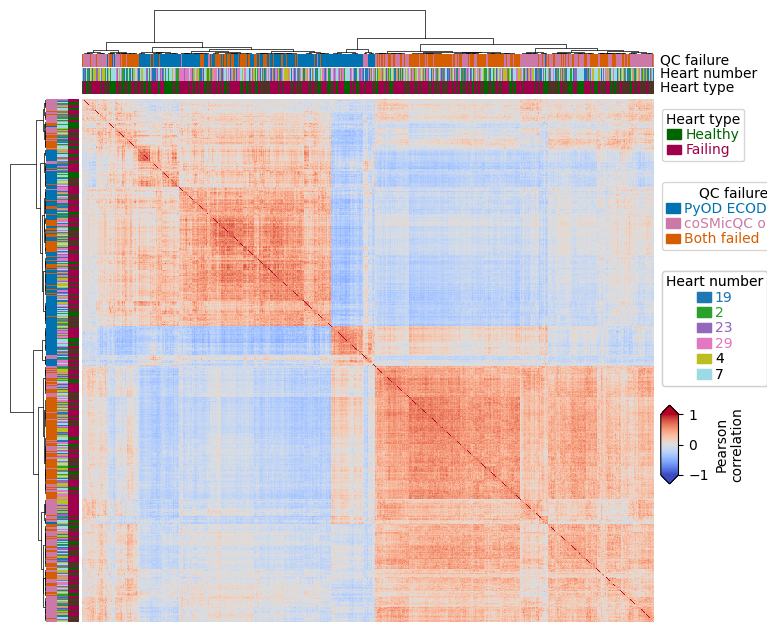

In [26]:
# -----------------------------
# CLEAN CORRELATION MATRIX
# -----------------------------
mat = corr_mat.copy()
mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)

for i in range(len(mat)):
    mat.iat[i, i] = 1.0

mat.index = mat.index.astype(str)
mat.columns = mat.columns.astype(str)

# -----------------------------
# QC LABELS
# -----------------------------
qc_status = pd.Series(cell_group_map).reindex(mat.index)
assert qc_status.isna().sum() == 0

# Rename QC labels for legend
qc_status = qc_status.replace(
    {
        "ecod_only": "PyOD ECOD only",
        "cosmic_only": "coSMicQC only",
        "failed_both": "Both failed",
    }
)

# -----------------------------
# HEART / CELL TYPE LABELS
# -----------------------------
cell_ids = mat.index

cell_annotations = pd.DataFrame({
    "heart_number": no_QC_df.loc[cell_ids, "Metadata_heart_number"].astype(str).values,
    "cell_type": no_QC_df.loc[cell_ids, "Metadata_cell_type"].astype(str).values,
    "group": qc_status.values,
}, index=cell_ids)

cell_types = cell_annotations["cell_type"].astype(str)
heart_numbers = cell_annotations["heart_number"].astype(str)

# -----------------------------
# COLORS
# -----------------------------
qc_colors = {
    "PyOD ECOD only": "#0072B2",
    "coSMicQC only": "#CC79A7",
    "Both failed": "#D55E00",
}

# Automatically generate colors for however
# many hearts are present
unique_hearts = sorted(heart_numbers.unique())

heart_cmap = plt.get_cmap("tab20")

heart_colors = {
    heart: heart_cmap(i / max(1, len(unique_hearts) - 1))
    for i, heart in enumerate(unique_hearts)
}

# Explicit cell type colors
cell_type_colors = {
    "Healthy": "#006400",
    "Failing": "#a0004b",
}

# -----------------------------
# ANNOTATIONS
# -----------------------------
row_anno = HeatmapAnnotation(
    **{
        "": anno_simple(
            qc_status,
            colors=qc_colors,
            legend=False,
        ),
        " ": anno_simple(
            heart_numbers,
            colors=heart_colors,
            legend=False,
        ),
        "  ": anno_simple(
            cell_types,
            colors=cell_type_colors,
            legend=False,
        ),
    },
    axis=0,
)

col_anno = HeatmapAnnotation(
    **{
        "QC failure": anno_simple(
            qc_status,
            colors=qc_colors,
            legend=True,
        ),
        "Heart number": anno_simple(
            heart_numbers,
            colors=heart_colors,
            legend=True,
        ),
        "Heart type": anno_simple(
            cell_types,
            colors=cell_type_colors,
            legend=True,
        ),
    },
    axis=1,
)

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(9, 7))

cm = ClusterMapPlotter(
    data=mat,

    top_annotation=col_anno,
    left_annotation=row_anno,

    cmap="coolwarm",
    vmin=-1,
    vmax=1,

    row_cluster=True,
    col_cluster=True,
    row_dendrogram=True,
    col_dendrogram=True,

    label="Pearson\ncorrelation",

    legend_anchor="ax_heatmap",
    legend_side="right",
    legend_width=5,
    legend_hpad=0,
    legend_vgap=5,
)

plt.subplots_adjust(left=0.18)

plt.savefig(
    "./figures/heatmap_failing_cells_p_correlation.png",
    bbox_inches="tight",
    dpi=600,
    pad_inches=0.5,
)

plt.show()